# Modelo de precio: resultados y sandbox

Este notebook **no entrena**. Carga el artefacto que dejó `src/train.py`
(`models/valora_modelo.joblib`), sus métricas y las predicciones out-of-fold, y lo pone a
prueba. Los notebooks son exploración; lo que corre en producción vive en `src/`.

Para reproducirlo desde cero:

```bash
docker compose run --rm reprocesar             # transform -> enrich -> load -> train
docker compose --profile notebooks up -d       # Jupyter en http://localhost:8888
```

Al final hay un **sandbox**: se edita un diccionario con las características de un inmueble
y el modelo devuelve el precio de venta y el canon de arriendo, cada uno con su rango.


In [1]:
import json
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

RAIZ = pathlib.Path("..").resolve()
sys.path.insert(0, str(RAIZ / "src"))
from predict import cargar_modelo, formatear, predecir  # noqa: E402

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110

modelo = cargar_modelo(RAIZ / "models" / "valora_modelo.joblib")
resumen = json.loads((RAIZ / "models" / "entrenamiento_resumen.json").read_text(encoding="utf-8"))
oof = pd.read_parquet(RAIZ / "models" / "predicciones_oof.parquet")
gold = pd.read_parquet(RAIZ / "data" / "processed" / "anuncios_enriquecido.parquet")

print(f"artefacto del {modelo['fecha']} | scikit-learn {modelo['sklearn']} | "
      f"{len(modelo['features'])} features | gold: {len(gold):,} filas")
for operacion, r in resumen["operaciones"].items():
    print(f"  {operacion:9} {r['filas']:>6,} filas | parámetros: {r['parametros']}")


artefacto del 2026-09-11 | scikit-learn 1.7.2 | 59 features | gold: 44,836 filas
  arriendo  22,386 filas | parámetros: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 500, 'learning_rate': 0.05, 'l2_regularization': 0.5}
  venta     22,859 filas | parámetros: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 500, 'learning_rate': 0.05, 'l2_regularization': 0.5}


## 1. Qué entra al modelo, y qué no

Entra lo que describe **al inmueble**: tamaño, distribución, estrato, antigüedad, piso,
comodidades, ubicación. No entra lo que describe **al anuncio** —fotos, inmobiliaria,
destacado— porque el sandbox tiene que valuar un inmueble que no está publicado, y porque
esas columnas predicen quién publica, no cuánto vale.

La tabla muestra la cobertura de cada feature en el gold: el modelo tolera nulos, pero una
feature con 30 % de cobertura aporta menos de lo que promete.


In [2]:
import train  # noqa: E402  (para leer los bloques de features tal como los define el pipeline)

bloques = {"categóricas": train.CATEGORICAS, "numéricas": train.NUMERICAS,
           "booleanas": train.BOOLEANAS, "comodidades": train.COMODIDADES}
derivadas = {"log_area": "area_m2", "log_administracion": "administracion"}
filas = []
for bloque, columnas in bloques.items():
    for columna in columnas:
        origen = derivadas.get(columna, columna)
        cobertura = gold[origen].notna().mean() * 100 if origen in gold.columns else np.nan
        filas.append({"bloque": bloque, "feature": columna, "cobertura_%": round(cobertura, 1)})
features = pd.DataFrame(filas)
display(features.groupby("bloque", sort=False).agg(n=("feature", "size"),
                                                   cobertura_min=("cobertura_%", "min"),
                                                   cobertura_media=("cobertura_%", "mean")).round(1))
print("excluidas a propósito:", ", ".join(train.EXCLUIDAS))
print("\ncobertura por feature (las que no llegan al 100 %):")
print(features[features["cobertura_%"] < 99.9].to_string(index=False))


,n,cobertura_min,cobertura_media
bloque,,,
categóricas,2,100.0,100.0
numéricas,11,44.5,88.9
booleanas,6,49.7,91.6
comodidades,40,100.0,100.0


excluidas a propósito: n_fotos, tiene_video, destacado, inmobiliaria_id, descripcion

cobertura por feature (las que no llegan al 100 %):
   bloque              feature  cobertura_%
numéricas         parqueaderos         99.7
numéricas              estrato         98.4
numéricas   antiguedad_ordinal         95.7
numéricas                 piso         44.5
numéricas   log_administracion         47.8
numéricas                  lat         97.6
numéricas                  lon         97.6
numéricas  distancia_centro_km         96.9
booleanas ubicacion_aproximada         49.7


## 2. Protocolo de evaluación

- **Un modelo por operación**, target `log(precio)`: el error relevante es relativo.
- **Split agrupado, siempre**, en dos regímenes:
  - `conocido`: `GroupKFold` por near-duplicado. Barrios ya vistos en train.
  - `frio`: `GroupKFold` por sector. El sector entero queda de un solo lado del split, así que
    el modelo tiene que valuar un barrio **que nunca vio**. Es el número que se parece a
    producción y el que hay que mirar primero.
- **Rango p10–p90** con dos modelos de cuantiles. Los cuantiles del boosting salen angostos,
  así que `train.py` los **calibra** con un factor medido out-of-fold hasta cubrir el 80 %.

Todo lo de esta sección sale de `models/entrenamiento_resumen.json`.


In [3]:
metricas = []
for operacion, r in resumen["operaciones"].items():
    for regimen in ("conocido", "frio"):
        m = r[regimen]
        metricas.append({"operacion": operacion, "régimen": regimen, "n": m["n"], "R²": m["R2"],
                         "MAE log": m["MAE_log"], "MAPE %": m["MAPE_%"], "MdAPE %": m["MdAPE_%"],
                         "dentro de ±10 %": m["dentro_10_%"], "dentro de ±20 %": m["dentro_20_%"]})
metricas = pd.DataFrame(metricas).set_index(["operacion", "régimen"])
display(metricas)

intervalo = pd.DataFrame({
    operacion: {
        "cobertura cruda p10-p90 %": r["conocido"]["cobertura_p10_p90_%"],
        "factor de calibración k": r["conocido"]["factor_intervalo"],
        "cobertura calibrada %": r["conocido"]["cobertura_calibrada_%"],
        "ancho relativo mediano crudo %": r["conocido"]["ancho_relativo_mediano_%"],
        "ancho relativo mediano calibrado %": r["conocido"]["ancho_calibrado_mediano_%"],
    } for operacion, r in resumen["operaciones"].items()})
display(intervalo)


n      R²  MAE log  MAPE %  MdAPE %  dentro de ±10 %  dentro de ±20 %
operacion régimen                                                                            
arriendo  conocido  22386  0.9106   0.1807   18.32    13.53            38.39            66.14
          frio      22386  0.9021   0.1907   19.24    14.67            36.25            63.27
venta     conocido  22859  0.9277   0.1713   17.39    12.83            40.75            68.67
          frio      22859  0.9224   0.1783   18.07    13.41            39.13            66.72

,arriendo,venta
cobertura cruda p10-p90 %,69.03,68.20
factor de calibración k,1.35,1.40
cobertura calibrada %,80.43,81.37
ancho relativo mediano crudo %,59.79,53.76
ancho relativo mediano calibrado %,87.09,82.27


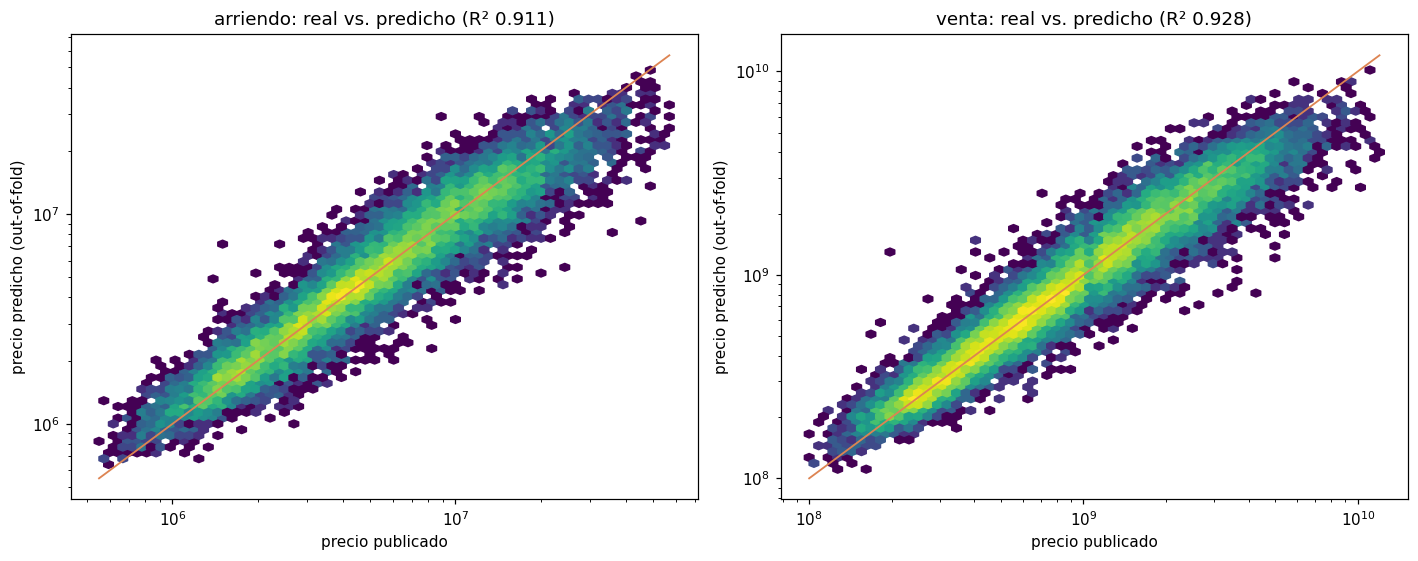

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5.2))
for eje, operacion in zip(ejes, resumen["operaciones"]):
    sub = oof[(oof["operacion"] == operacion) & (oof["regimen"] == "conocido")]
    real, pred = np.exp(sub["y_log"]), np.exp(sub["pred_log"])
    eje.hexbin(real, pred, gridsize=60, bins="log", xscale="log", yscale="log", cmap="viridis")
    limites = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    eje.plot(limites, limites, color="#DD8452", linewidth=1.2)
    eje.set_xlabel("precio publicado")
    eje.set_ylabel("precio predicho (out-of-fold)")
    r2 = resumen["operaciones"][operacion]["conocido"]["R2"]
    eje.set_title(f"{operacion}: real vs. predicho (R² {r2:.3f})")
plt.tight_layout()
plt.show()


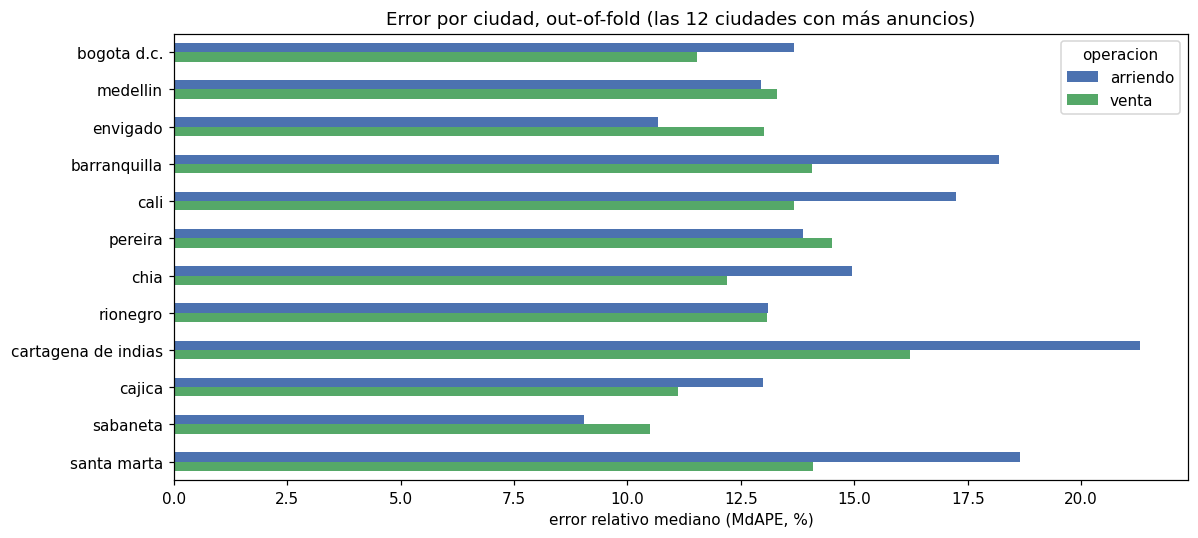

operacion,arriendo,venta
ciudad_clave,,
bogota d.c.,13.7,11.5
medellin,12.9,13.3
envigado,10.7,13.0
barranquilla,18.2,14.1
cali,17.2,13.7
pereira,13.9,14.5
chia,15.0,12.2
rionegro,13.1,13.1
cartagena de indias,21.3,16.2


In [5]:
# Dónde se equivoca más el modelo: error relativo mediano por ciudad, régimen conocido
oof["error_rel_%"] = np.abs(np.expm1(oof["pred_log"] - oof["y_log"])) * 100
conocido = oof[oof["regimen"] == "conocido"]
principales = conocido["ciudad_clave"].value_counts().head(12).index
por_ciudad = (conocido[conocido["ciudad_clave"].isin(principales)]
              .groupby(["ciudad_clave", "operacion"])["error_rel_%"].median().unstack())
por_ciudad = por_ciudad.loc[principales]

fig, eje = plt.subplots(figsize=(11, 5))
por_ciudad.plot.barh(ax=eje, color=["#4C72B0", "#55A868"])
eje.invert_yaxis()
eje.set_xlabel("error relativo mediano (MdAPE, %)")
eje.set_ylabel("")
eje.set_title("Error por ciudad, out-of-fold (las 12 ciudades con más anuncios)")
plt.tight_layout()
plt.show()
display(por_ciudad.round(1))


## 3. Qué pesa

Importancia por permutación sobre un fold de test: cuánto empeora el MAE (en log) al barajar
cada feature. No dice causalidad, dice de qué depende el modelo.


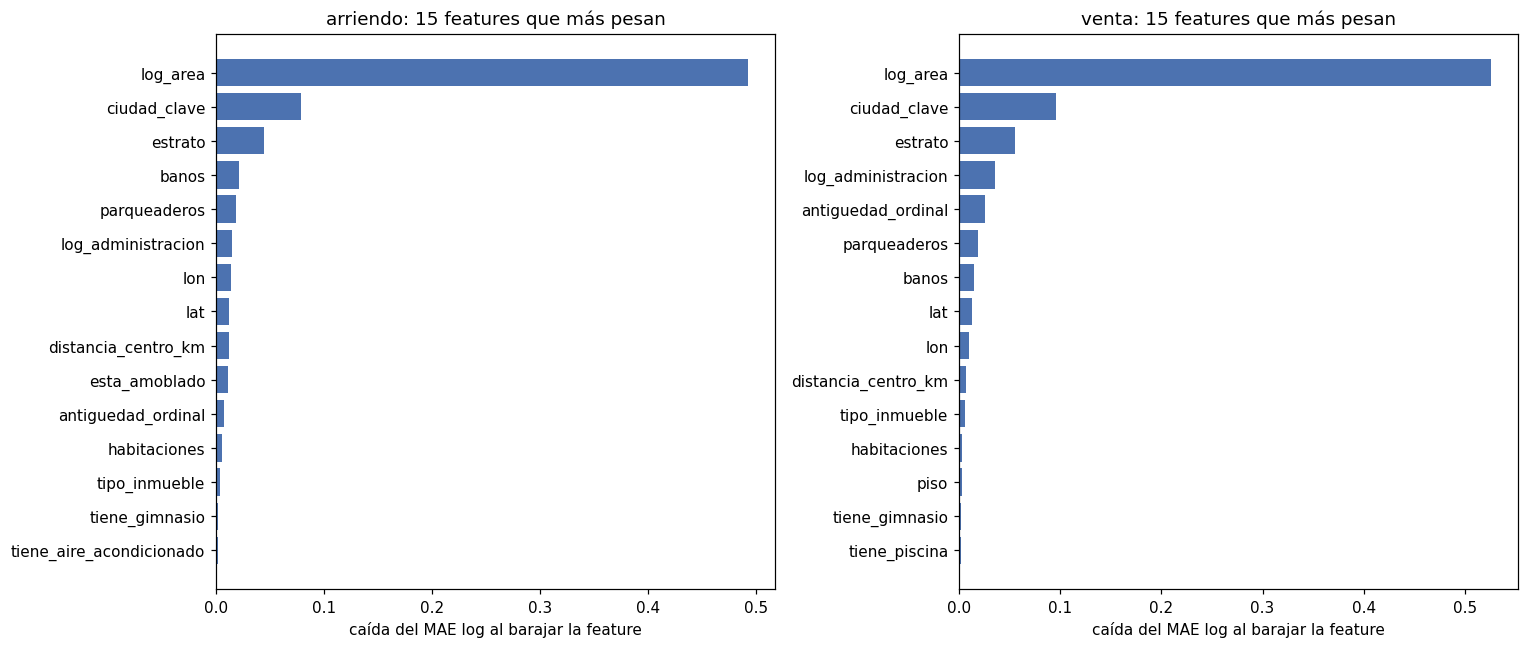

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 6))
for eje, (operacion, importancias) in zip(ejes, modelo["importancias"].items()):
    top = pd.Series(importancias).head(15)[::-1]
    eje.barh(top.index, top.values, color="#4C72B0")
    eje.set_title(f"{operacion}: 15 features que más pesan")
    eje.set_xlabel("caída del MAE log al barajar la feature")
plt.tight_layout()
plt.show()


## 4. Los errores más grandes

Mirarlos uno por uno es la auditoría más barata del dataset: un error del 300 % casi nunca
es del modelo. Es un precio mal cargado, un área que no corresponde o un anuncio que dice
una cosa en el título y otra en la ficha.


In [7]:
# tipo_inmueble y ciudad_clave ya vienen en el OOF: no se repiten en el merge
columnas = ["url", "ciudad", "sector", "area_m2", "estrato", "habitaciones"]
peores = []
for operacion, columna in (("venta", "precio_venta"), ("arriendo", "precio_arriendo")):
    sub = conocido[conocido["operacion"] == operacion].nlargest(8, "error_rel_%")
    detalle = sub.merge(gold[["id_inmueble"] + columnas], on="id_inmueble", how="left")
    detalle["real"] = np.exp(detalle["y_log"]).round()
    detalle["predicho"] = np.exp(detalle["pred_log"]).round()
    detalle["operacion"] = operacion
    peores.append(detalle[["operacion", "ciudad", "sector", "tipo_inmueble", "area_m2", "estrato",
                           "real", "predicho", "error_rel_%", "url"]])
peores = pd.concat(peores, ignore_index=True)
pd.set_option("display.max_colwidth", 70)
display(peores.round(0))


,operacion,ciudad,sector,tipo_inmueble,area_m2,estrato,real,predicho,error_rel_%,url
0,venta,Bogotá D.C.,Santa Barbara Oriental,casa,150.0,5,200000000.0,1.269247e+09,535.0,https://www.metrocuadrado.com/inmueble/arriendo-casa-bogota-santa-...
1,venta,La Mesa,Condominio Guanumby,casa,207.0,4,400000000.0,1.464691e+09,266.0,https://www.metrocuadrado.com/inmueble/venta-casa-la-mesa-condomin...
2,venta,Cartagena De Indias,Variante Turbaco,casa,350.0,1,680000000.0,2.475439e+09,264.0,https://www.metrocuadrado.com/inmueble/venta-casa-cartagena-de-ind...
3,venta,Anapoima,Cn Anapoima,casa,205.0,6,400000000.0,1.438769e+09,260.0,https://www.metrocuadrado.com/inmueble/venta-casa-anapoima-4-habit...
4,venta,Oicata,Oicata,casa,190.0,<NA>,390000000.0,1.284586e+09,229.0,https://www.metrocuadrado.com/inmueble/venta-casa-oicata-oicata-4-...
5,venta,Bogotá D.C.,Gran America,apartaestudio,53.0,4,180000000.0,5.668575e+08,215.0,https://www.metrocuadrado.com/inmueble/venta-apartaestudio-bogota-...
6,venta,Pereira,Alamos,casa,548.0,6,560000000.0,1.717250e+09,207.0,https://www.metrocuadrado.com/inmueble/arriendo-casa-pereira-los-a...
7,venta,Santa Marta,El Rodadero Rodadero Y Gaira,apartamento,61.0,<NA>,171500000.0,5.236523e+08,205.0,https://www.metrocuadrado.com/inmueble/venta-apartamento-santa-mar...
8,arriendo,Cartagena De Indias,Manzanillo Del Mar,apartamento,158.0,6,1500000.0,6.976415e+06,365.0,https://www.metrocuadrado.com/inmueble/venta-apartamento-cartagena...
9,arriendo,Medellín,Santa Elena,casa,120.0,<NA>,1370000.0,4.956002e+06,262.0,https://www.metrocuadrado.com/inmueble/arriendo-casa-medellin-sant...


## 5. Sandbox

Editá el diccionario y ejecutá las dos celdas. Campos:

| campo | valores | si falta |
|---|---|---|
| `ciudad` | como la escribe el sitio: `"Bogotá D.C."`, `"Medellín"`, `"Cali"`… | obligatorio |
| `sector` | el barrio o sector, como lo escriben los anunciantes | se usa el centro de la ciudad |
| `tipo` | `apartaestudio`, `apartamento`, `casa` | `apartamento` |
| `area_m2` | área construida | obligatorio |
| `estrato` | 1 a 6 | mediana del sector |
| `antiguedad` | `"Menos de 1 año"`, `"Entre 0 y 5 años"`, `"Entre 5 y 10 años"`, `"Entre 10 y 20 años"`, `"Más de 20 años"` | nulo |
| `habitaciones`, `banos`, `parqueaderos`, `piso`, `administracion` | números | nulo |
| `comodidades` | lista con nombres cortos: `ascensor`, `piscina`, `gimnasio`, `conjunto_cerrado`, `vigilancia`, `cctv`, `citofono`, `salon_comunal`, `zonas_verdes`, `zona_ninos`, `bbq`, `canchas`, `sauna`, `jacuzzi`, `parqueadero_visitantes`, `parqueadero_cubierto`, `planta_electrica`, `balcon`, `terraza`, `chimenea`, `deposito`, `estudio`, `cocina_integral`, `cuarto_servicio`, `bano_servicio`, `jardin`, `vista_exterior`, `vista_panoramica`, `aire_acondicionado`, `calefaccion`, `walking_closet`, `amoblado`, `monoambiente`, `mascotas`, `rural`, `transporte`, `colegios`, `parques`, `supermercados`, `centros_comerciales` | ninguna |
| `es_nuevo` | `True` / `False` | `False` |
| `lat`, `lon` | coordenada exacta, si la tenés | se resuelve por sector |

El resultado dice de dónde salió cada dato que no diste (`contexto`), así se sabe cuánto
confiar: un sector con 300 comparables no es lo mismo que uno que el modelo nunca vio.


In [8]:
inmueble = {
    "ciudad": "Bogotá D.C.",
    "sector": "Chicó Norte",
    "tipo": "apartamento",
    "area_m2": 85,
    "habitaciones": 2,
    "banos": 2,
    "parqueaderos": 1,
    "estrato": 6,
    "antiguedad": "Entre 5 y 10 años",
    "piso": 4,
    "comodidades": ["ascensor", "gimnasio", "vigilancia", "deposito"],
}


In [9]:
def pesos(valor):
    return "$ " + f"{valor:,.0f}".replace(",", ".")


def tarjeta(resultado, inmueble):
    contexto = resultado["contexto"]
    bloques = ""
    for operacion, color in (("venta", "#2E7D32"), ("arriendo", "#1565C0")):
        r = resultado[operacion]
        bloques += f"""
        <div style="flex:1;min-width:260px;padding:16px 20px;border-radius:12px;background:#f7f8fa;border-left:6px solid {color}">
          <div style="font-size:12px;letter-spacing:.08em;text-transform:uppercase;color:#666">{operacion}{' (canon mensual)' if operacion == 'arriendo' else ''}</div>
          <div style="font-size:30px;font-weight:700;color:{color};margin:4px 0">{pesos(r['estimado'])}</div>
          <div style="color:#444">rango 80 %: {pesos(r['rango'][0])} – {pesos(r['rango'][1])}</div>
          <div style="color:#444">{pesos(r['precio_m2'])} / m²</div>
        </div>"""
    return f"""
    <div style="font-family:system-ui,Segoe UI,Roboto,sans-serif;max-width:820px;padding:20px 24px;border:1px solid #e3e5e8;border-radius:16px">
      <div style="font-size:20px;font-weight:600">{inmueble.get('tipo','apartamento').capitalize()} de {inmueble['area_m2']} m² · {contexto['sector'] or 'sin sector'}, {contexto['ciudad']}</div>
      <div style="color:#666;margin:4px 0 14px">estrato {contexto['estrato_usado']} ({contexto['origen_estrato']}) ·
        coordenada: {contexto['origen_coordenada']} · {contexto['distancia_centro_km']} km del centro ·
        {'sector conocido, ' + str(contexto['n_comparables_sector']) + ' comparables' if contexto['sector_conocido'] else 'sector nunca visto por el modelo'}</div>
      <div style="display:flex;gap:16px;flex-wrap:wrap">{bloques}</div>
      <div style="margin-top:14px;color:#444">Rentabilidad bruta anual implícita (12 × canon / venta): <b>{resultado['rentabilidad_bruta_anual_%']} %</b></div>
    </div>"""


resultado = predecir(modelo, inmueble)
display(HTML(tarjeta(resultado, inmueble)))
print(formatear(resultado))


Bogotá D.C. - Chicó Norte (sector conocido, 289 comparables)
  coordenada: sector | estrato 6 (usuario) | 1.074 km del centro
  venta     $ 909.767.285   rango $ 614.209.570 - $ 967.872.696 | $ 10.703.145/m²
  arriendo  $ 5.544.097   rango $ 4.788.063 - $ 7.842.330 | $ 65.225/m²
  rentabilidad bruta anual implícita: 7.31 %


### Sensibilidad: el mismo inmueble, cambiando una cosa a la vez

Una forma rápida de ver si el modelo aprendió reglas del mercado o memorizó anuncios: el
precio tiene que subir con el estrato, con el área y con las comodidades, y bajar con la
antigüedad, de forma monótona y en magnitudes creíbles.


In [10]:
def variar(base, campo, valores):
    filas = []
    for valor in valores:
        r = predecir(modelo, {**base, campo: valor})
        filas.append({campo: valor, "venta": r["venta"]["estimado"], "arriendo": r["arriendo"]["estimado"],
                      "venta_m2": r["venta"]["precio_m2"]})
    tabla = pd.DataFrame(filas).set_index(campo)
    tabla["venta_vs_base_%"] = ((tabla["venta"] / tabla["venta"].iloc[0] - 1) * 100).round(1)
    return tabla

print("estrato:")
display(variar(inmueble, "estrato", [2, 3, 4, 5, 6]))
print("área (m²):")
display(variar(inmueble, "area_m2", [45, 65, 85, 120, 180]))
print("antigüedad:")
display(variar(inmueble, "antiguedad", ["Menos de 1 año", "Entre 0 y 5 años", "Entre 5 y 10 años",
                                        "Entre 10 y 20 años", "Más de 20 años"]))


estrato:


,venta,arriendo,venta_m2,venta_vs_base_%
estrato,,,,
2,522838703,4401021,6151044,0.0
3,554284695,4513032,6520996,6.0
4,642478789,4682714,7558574,22.9
5,740174930,5227670,8707940,41.6
6,909767285,5544097,10703145,74.0


área (m²):


,venta,arriendo,venta_m2,venta_vs_base_%
area_m2,,,,
45,558345945,3846750,12407688,0.0
65,717041940,4734459,11031414,28.4
85,909767285,5544097,10703145,62.9
120,1238163046,7207600,10318025,121.8
180,1669471826,9705194,9274843,199.0


antigüedad:


,venta,arriendo,venta_m2,venta_vs_base_%
antiguedad,,,,
Menos de 1 año,969062238,5682991,11400732,0.0
Entre 0 y 5 años,969062238,5682991,11400732,0.0
Entre 5 y 10 años,909767285,5544097,10703145,-6.1
Entre 10 y 20 años,839707751,5469962,9878915,-13.3
Más de 20 años,695629288,5458460,8183874,-28.2


In [11]:
# Otro mercado, otro tipo: una casa en Medellín
casa = {"ciudad": "Medellín", "sector": "Laureles", "tipo": "casa", "area_m2": 180,
        "habitaciones": 4, "banos": 3, "parqueaderos": 2, "estrato": 5,
        "antiguedad": "Entre 10 y 20 años", "comodidades": ["terraza", "estudio"]}
resultado_casa = predecir(modelo, casa)
display(HTML(tarjeta(resultado_casa, casa)))


## 6. Límites, dichos con claridad

- **Es precio de publicación, no de cierre.** El dataset son anuncios de un portal en un
  momento (septiembre de 2026): lo que piden, no lo que pagan. El modelo hereda ese sesgo.
- **Una foto en el tiempo.** Sin historial no hay tendencia; el pipeline periódico existe
  para acumularla, y con dos o tres snapshots el modelo puede aprender la variación.
- **Arranque en frío.** El número del régimen `frio` es el que vale para un barrio nuevo. Si
  el sector no está en el gazetteer interno, la coordenada cae en el centro de la ciudad y
  el rango se ensancha por una razón.
- **Cobertura de las columnas nuevas.** Administración, área privada y piso no vienen en
  todos los anuncios; el modelo los usa cuando están y los ignora cuando no.

Lo que seguiría: acumular snapshots, y una API mínima sobre `src/predict.py`.
